In [11]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt



In [12]:
data = pd.read_csv('grade_students.txt', sep='\t')


In [13]:
data.head()

,g1freelunch,g1absent,g1readscore,g1mathscore,g1listeningscore,g1wordscore
0,1,9,516,578,601,493
1,0,12,451,507,584,436
2,1,4,483,526,529,486
3,1,15,516,505,556,536
4,1,2,433,463,504,426


In [14]:
X = np.array(data.values)
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [15]:
I, N = data.shape[0], data.shape[1]
K = 3


max_iter = 100


In [16]:
def assign_clusters(X, U):
    distances = np.sum((X[:, np.newaxis] - U)**2, axis=2)
    return np.argmin(distances, axis=1)

def update_U(X, labels, K):
    new_U = []
    for k in range(K):
        points = X[labels == k]
        if len(points) > 0:
            new_U.append(points.mean(axis=0))
        else:
            new_U.append(X[np.random.randint(0, X.shape[0])])
    return np.array(new_U)

In [17]:
# K-means
for iteration in range(max_iter):
    labels = assign_clusters(X, U)
    new_U = update_U(X, labels, K)

    # convergence
    if np.allclose(U, new_U):
        print("Convergence atteinte à l'itération", iteration)
        break

    U = new_U

Convergence atteinte à l'itération 0


In [18]:
data['cluster'] = labels



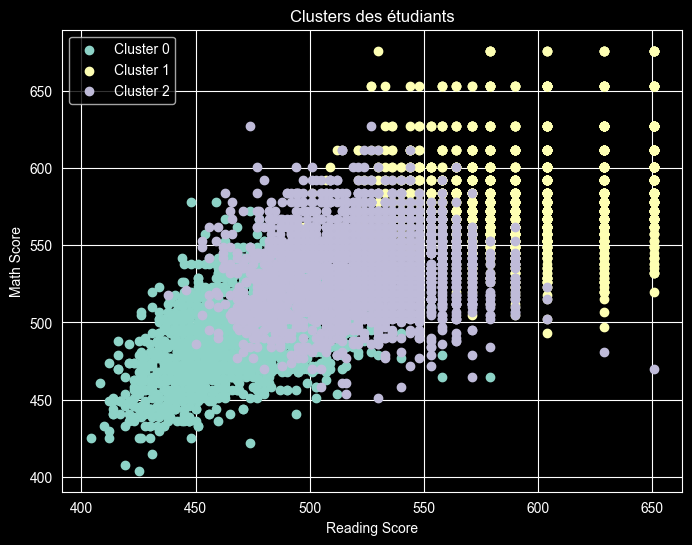

In [19]:
# 2D Visualization of Student Clusters
plt.figure(figsize=(8,6))

for k in range(3):
    cluster_data = data[data['cluster'] == k]

    plt.scatter(
        cluster_data['g1readscore'],
        cluster_data['g1mathscore'],
        label=f'Cluster {k}'
    )

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Clusters des étudiants")
plt.legend()
plt.show()

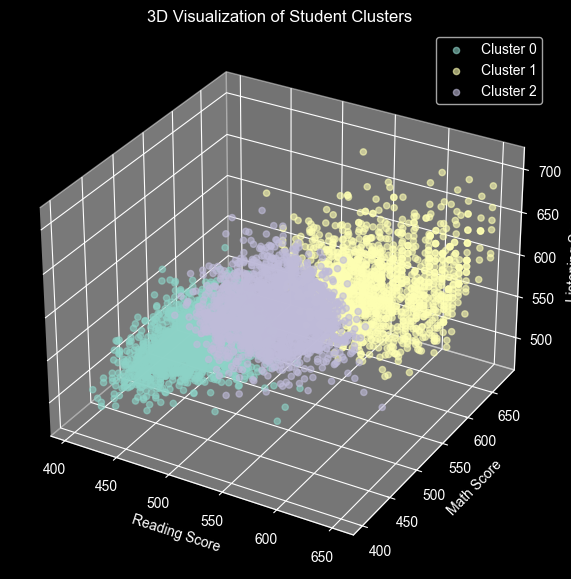

In [20]:
# 3D Visualization of Student Clusters
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for k in range(3):
    cluster_data = data[data['cluster'] == k]

    ax.scatter(
        cluster_data['g1readscore'],
        cluster_data['g1mathscore'],
        cluster_data['g1listeningscore'],
        label=f'Cluster {k}',
        alpha=0.6
    )

ax.set_xlabel("Reading Score")
ax.set_ylabel("Math Score")
ax.set_zlabel("Listening Score")
ax.set_title("3D Visualization of Student Clusters")
ax.legend()

plt.show()